# Select reports for manual labelling

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import datetime as dt
from src.text_processing_functions import *
from src.LLM_functions import *
import copy as cp
import geopandas as gpd
import matplotlib.pyplot as plt

from src.data import *
from src.labelling_helpers import *
from src.data_format import format_output
from src.geocoding_utils import get_continent
from src.visualisation import *

path_save_fig = DATA_FIGURE / "manual_labelling" 

In [5]:
input_reports_expanded = pd.read_csv(DATA_IN_JSONS / "preproc_text_sel_gaps_df_with_clean_text_all_combined_v300626_v060726.csv")
ymin=2016
ymax=2025
input_reports_expanded = input_reports_expanded.drop_duplicates(subset=["appealCode", "reportDate"])
input_reports_expanded["reportYear"] = pd.to_datetime(input_reports_expanded["reportDate"], errors="coerce", infer_datetime_format=True).dt.year
input_reports_expanded = input_reports_expanded.loc[(input_reports_expanded["reportYear"]>=ymin) & (input_reports_expanded["reportYear"]<=ymax)]

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_31392\698011929.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  input_reports_expanded["reportYear"] = pd.to_datetime(input_reports_expanded["reportDate"], errors="coerce", infer_datetime_format=True).dt.year


In [9]:
# fname_in_old = "preproc_text_sel_gaps_df_with_clean_text_all_v300626"
# input_reports_old = pd.read_csv(DATA_IN_JSONS / (fname_in_old + ".csv"))
# input_reports_old["reportDate"] = pd.to_datetime(input_reports_old["reportDate"],errors="coerce")

# fname_in = "preproc_text_sel_gaps_all_reports_with_pdf_status_020726_with_clean_text_v030726"
# input_reports = pd.read_csv(DATA_IN_JSONS / (fname_in + ".csv"))
# input_reports["reportDate"] = pd.to_datetime(input_reports["reportDate"],errors="coerce")

# # Add years from reportDate 
# years = pd.to_datetime(input_reports["reportDate"], errors="coerce", infer_datetime_format=True).dt.year
# input_reports["reportYear"] = years

# years = pd.to_datetime(input_reports_old["reportDate"], errors="coerce", infer_datetime_format=True).dt.year
# input_reports_old["reportYear"] = years

In [8]:
# # Update the input_reports
# missing_rows = input_reports_old.merge(
#     input_reports[['appealCode', 'reportDate']],
#     on=['appealCode', 'reportDate'],
#     how='left',
#     indicator=True
# )

# missing_rows = missing_rows[missing_rows['_merge'] == 'left_only'].drop(columns='_merge')

# # Append them to the current reports
# input_reports_expanded = pd.concat([input_reports, missing_rows],ignore_index=True)
# # input_reports_expanded.to_csv(DATA_IN_JSONS / "preproc_text_sel_gaps_df_with_clean_text_all_combined_v300626_v060726.csv", index=False)

In [ ]:
# # Open labelled reports 
# fname_Gabi = "labelled_reports_round2_Gabriela"
# fname_Ana = "labelled_reports_round2_ANA"
# fname_Cc = "red_crosslabelled_reports_cecily"
# fname_Luca = "labelled_reports_impacts_luca_gaps_v260626"
# fname_Laura = "labelled_impact_"
# appeals_Laura = ["MDRCN006", "MDRBD022", "MDRYE011", "MDRS2001", "MDRIQ014", 
#                  "MDRSV012", "MDRMY003", "MDRKE058", "MDRNG041", 
#                  "MDRZM022", "MDRUG050", "MDRUY004", "MDRKZ010", "MDREC019", 
#                  "MDRPG008", "MDRTJ035", "MDRPK018", "MDRMN017", "MDRRS015"]

# dfs = [
#     pd.read_csv(DATA_LABELLED / f"{fname_Gabi}.csv"),
#     pd.read_csv(DATA_LABELLED / f"{fname_Ana}.csv"),
#     pd.read_csv(DATA_LABELLED / f"{fname_Cc}.csv"),
#     pd.read_csv(DATA_LABELLED / f"{fname_Luca}.csv"),
# ]

# # Read Laura's files
# dfs.extend(
#     pd.read_csv(DATA_LABELLED / f"{fname_Laura}{appeal}.csv")
#     for appeal in appeals_Laura
# )

# # Combine everything
# labelled_reports = pd.concat(dfs, ignore_index=True)
# labelled_reports["reportDate"] = pd.to_datetime(labelled_reports["reportDate"],format="mixed",dayfirst=True,errors="coerce")
# # labelled_reports["reportDate"] = pd.to_datetime(labelled_reports["reportDate"],errors="coerce")

# # Save into a unique file
# labelled_reports.to_csv(DATA_LABELLED / "combined_labelled_reports.csv", index=False)

In [11]:
labelled_reports = pd.read_csv(DATA_LABELLED / "combined_labelled_reports.csv")

In [12]:
mask = (
    labelled_reports["impactValue"].isna()
    & labelled_reports["impactValueMin"].isna()
    & labelled_reports["impactValueMax"].isna()
)

print(len(labelled_reports.loc[mask]),"rows with qualitative impact")
print(len(labelled_reports.loc[~mask]),"rows with quantitative impact")
print(len(labelled_reports),"rows with impact")

274 rows with qualitative impact
549 rows with quantitative impact
823 rows with impact


In [13]:
# Span of the impact subtypes 
labelled_reports.impactSubType.nunique()

31

In [14]:
# Verify that matching can be done 
input_reports_labelled = input_reports_expanded.merge(labelled_reports[["appealCode", "reportDate"]], how="inner", on=["appealCode", "reportDate"])
input_reports_labelled = input_reports_labelled.drop_duplicates()

In [15]:
# Look for the appealCodes that are in the labelled reports but not in the input_reports
labelled_appealCodes = set(input_reports_labelled["appealCode"])
input_appealCodes = set(input_reports_labelled["appealCode"])
unmatched_appealCodes = labelled_appealCodes - input_appealCodes
print(f"Number of appealCodes in labelled reports but not in input_reports: {len(unmatched_appealCodes)}")

Number of appealCodes in labelled reports but not in input_reports: 0


# Invertigate number of sentences per reports 

In [125]:
col_to_list = ["nathaz_text"]
input_reports_labelled[col_to_list] = input_reports_labelled[col_to_list].map(lambda x: listify_strings(x))

In [ ]:
lengths = input_reports_labelled["nathaz_text"].apply(lambda x: len(x))

summary = {
    "mean": lengths.mean(),
    "median": lengths.median(),
    "min": lengths.min(),
    "max": lengths.max(), 
    "total": lengths.sum()
}

summary

{'mean': np.float64(36.743589743589745), 'median': 28.0, 'min': 8, 'max': 199}

# Vizualise hazards and locations

In [111]:
# Hazards into list 
col_to_list = ["hazards_found_kw"]
input_reports_labelled[col_to_list] = input_reports_labelled[col_to_list].map(lambda x: listify_strings(x))

In [112]:
# Add continent information to the reports
world = gpd.read_file(ADMIN_PATH / "ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
reports_to_label = input_reports_labelled.merge(
    world[["ISO_A3", "CONTINENT"]],
    how="left",
    left_on="iso_code",
    right_on="ISO_A3",
)
reports_to_label = reports_to_label.rename(columns={"CONTINENT": "continent"})

In [113]:
df = reports_to_label.explode('continent').explode('hazards_found_kw')
df = df.dropna(subset=['continent'])
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards_found_kw'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards_found_kw'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_25928\4184518070.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


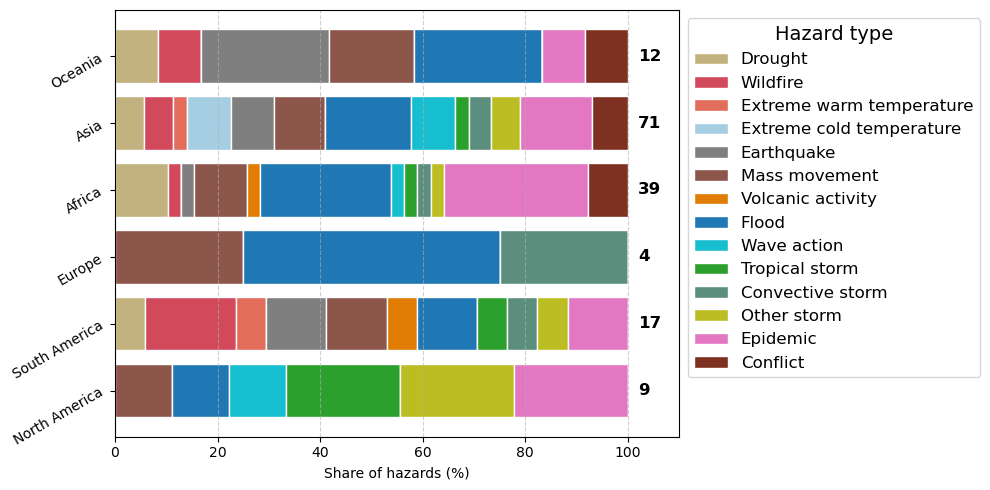

In [115]:
continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia',  'Oceania']

# Ensure the columns follow the order of hazard_colormap
# hazard_order = [h for h in hazard_colormap.keys() if h in hazard_counts.columns]
hazard_counts = hazard_counts.loc[continent_order]
hazard_counts = hazard_counts[hazard_order]

# Convert to percentage per continent
hazard_counts_percent = hazard_counts.div(hazard_counts.sum(axis=1), axis=0) * 100
hazard_counts_total = hazard_counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

left = [0] * len(hazard_counts)
for hazard in hazard_counts.columns:
    ax.barh(
        hazard_counts.index,
        hazard_counts_percent[hazard],
        left=left,
        color=hazard_colormap.get(hazard, 'gray'),
        edgecolor='white',
        label=hazard
    )
    left += hazard_counts_percent[hazard].values

# Add total counts at end of each bar
for i, total in enumerate(hazard_counts_total):
    ax.text(102, i, f'{total}', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(0, 110)
ax.set_xlabel('Share of hazards (%)')
ax.set_ylabel('')
# ax.set_title('Distribution of Hazard Types by Continent', fontweight='bold')

# Add vertical gridlines from x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Rotate y-axis labels slightly
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Legend
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hazard type', title_fontsize=14, fontsize=12)

# Save fig
fig.savefig(path_save_fig / f"hazard_share_continents.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_25928\4279190293.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hazard_order, fontsize=fontsize, rotation=20, ha="right")


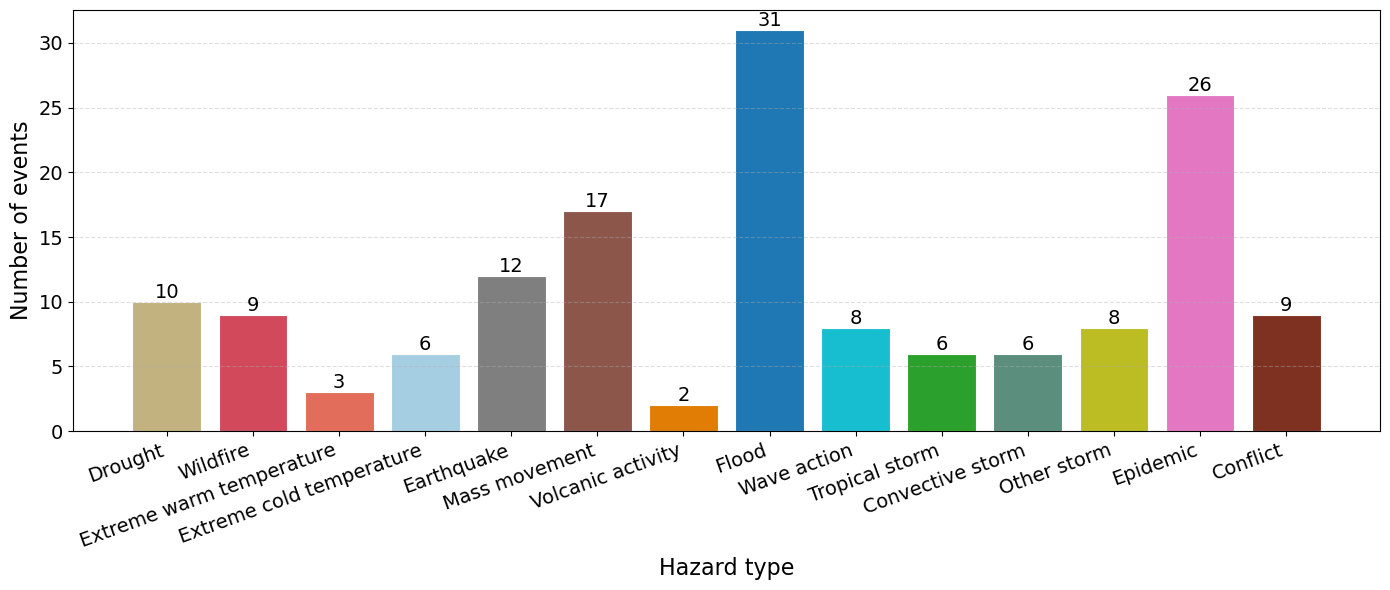

In [116]:
# Bar plot: hazard type vs number of events
hazard_counts = (
    reports_to_label.explode("hazards_found_kw")
    .dropna(subset=["hazards_found_kw"])["hazards_found_kw"]
    .value_counts()
    .rename_axis("hazards_found_kw")
    .reset_index(name="n_events")
)

if "hazard_order" in globals():
    hazard_counts["hazards_found_kw"] = pd.Categorical(
        hazard_counts["hazards_found_kw"],
        categories=hazard_order,
        ordered=True,
    )
    hazard_counts = hazard_counts.sort_values("hazards_found_kw")
else:
    hazard_counts = hazard_counts.sort_values("n_events", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fontsize=14
bar_colors = [hazard_colormap.get(hazard, "gray") for hazard in hazard_counts["hazards_found_kw"]]
bars = ax.bar(
    hazard_counts["hazards_found_kw"].astype(str),
    hazard_counts["n_events"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)

ax.set_xlabel("Hazard type", fontsize=fontsize+2)
ax.set_ylabel("Number of events", fontsize=fontsize+2)
# ax.set_title("Number of events by hazard type", fontsize=fontsize+3)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xticklabels(hazard_order, fontsize=fontsize, rotation=20, ha="right")

for bar, value in zip(bars, hazard_counts["n_events"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=fontsize,
    )
fig.savefig(path_save_fig / f"hazard_share.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [107]:
reports_to_label[["appealCode", "reportDate", "reportLink"]].to_csv(DATA_LABELLED / "combined_labelled_reports_info.csv", index=False)